In [11]:
import os
import numpy as np  
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer

In [16]:

df_path = os.path.join("..", "data", "combined.csv")   # ../data/combined.csv from src/
assert os.path.exists(df_path), f"File not found: {df_path}"
df = pd.read_csv(df_path)
df.head(15)

,ResponseId,Age,Gender,shopping_freq,cookie,cup,sneakers,headphones,perfume,treated
0,R_62VbvFjFQg4WgaI,2,1,1,10,30,100,120,50,0
1,R_6Opo6OBKtseV0RH,2,1,2,20,50,200,150,100,1
2,R_6CZq1yFVklcfk5P,3,2,2,90,70,100,150,150,1


In [17]:
df = df.dropna()
df = df[df[['cookie','sneakers']].notna().all(axis=1)]

In [18]:
df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})
df

,ResponseId,Age,Gender,shopping_freq,cookie,cup,sneakers,headphones,perfume,treated,Treatment_factor
0,R_62VbvFjFQg4WgaI,2,1,1,10,30,100,120,50,0,Control
1,R_6Opo6OBKtseV0RH,2,1,2,20,50,200,150,100,1,Treatment
2,R_6CZq1yFVklcfk5P,3,2,2,90,70,100,150,150,1,Treatment


# ATE Without regression

In [19]:
# ...existing code...
exp_cols = ['cookie','cup','sneakers','headphones','perfume']

# ensure using the notebook dataframe variable (df)
results = {}
for col in exp_cols:
    if col not in df.columns:
        results[col] = {"error": "missing"}
        continue

    # convert to numeric where appropriate
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()
    n_ctr = series[df['treated'] == 0].notna().sum()
    n_trt = series[df['treated'] == 1].notna().sum()
    diff = mean_trt - mean_ctr

    results[col] = {
        "mean_control": mean_ctr,
        "mean_treatment": mean_trt,
        "diff": diff,
        "n_control": int(n_ctr),
        "n_treatment": int(n_trt)
    }

# keep results in a variable and print
exp_results = results
exp_results

{'cookie': {'mean_control': np.float64(10.0),
  'mean_treatment': np.float64(55.0),
  'diff': np.float64(45.0),
  'n_control': 1,
  'n_treatment': 2},
 'cup': {'mean_control': np.float64(30.0),
  'mean_treatment': np.float64(60.0),
  'diff': np.float64(30.0),
  'n_control': 1,
  'n_treatment': 2},
 'sneakers': {'mean_control': np.float64(100.0),
  'mean_treatment': np.float64(150.0),
  'diff': np.float64(50.0),
  'n_control': 1,
  'n_treatment': 2},
 'headphones': {'mean_control': np.float64(120.0),
  'mean_treatment': np.float64(150.0),
  'diff': np.float64(30.0),
  'n_control': 1,
  'n_treatment': 2},
 'perfume': {'mean_control': np.float64(50.0),
  'mean_treatment': np.float64(125.0),
  'diff': np.float64(75.0),
  'n_control': 1,
  'n_treatment': 2}}

# Estimating the ATE with regression


## with only treatment as one covariate


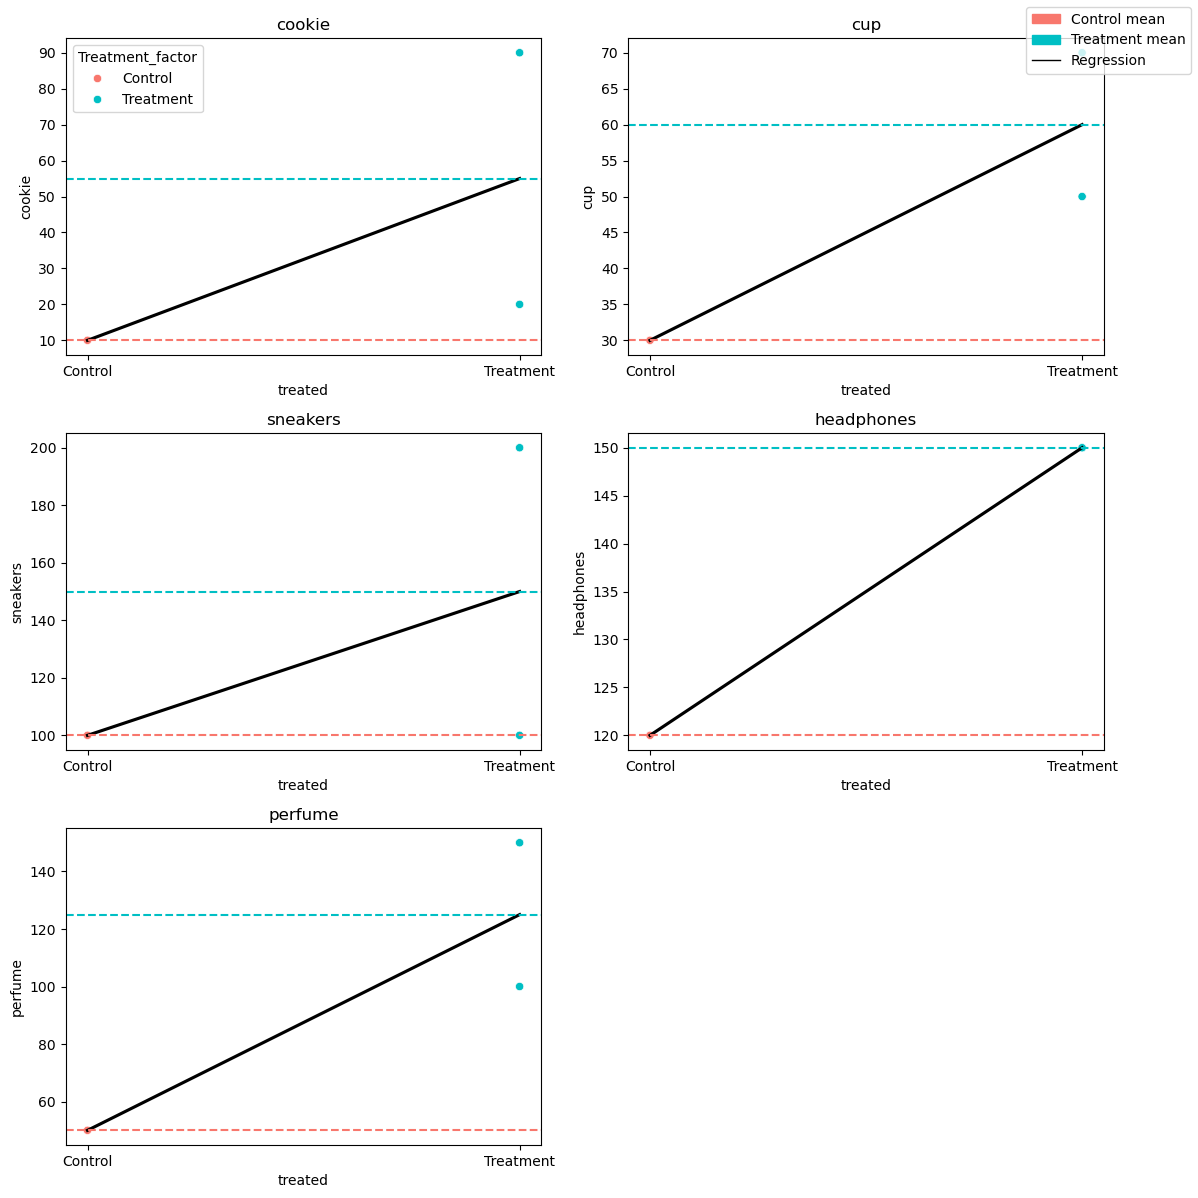

In [28]:
# Replace plotting cell with this code (plots one panel per column)
import math
import matplotlib.patches as mpatches

exp_cols = ['cookie','cup','sneakers','headphones','perfume']
cols_present = [c for c in exp_cols if c in df.columns]
if len(cols_present) == 0:
    raise RuntimeError("None of the expected experiment columns found in df.")

# ensure Treatment_factor exists
if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    # numeric series for plotting/stats
    series = pd.to_numeric(df[col], errors='coerce')

    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    # scatterplot (show legend only on first plot)
    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)

    # regression line
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                label='Regression', ci=None, ax=ax)

    # mean lines
    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'], label='Mean Control' if show_legend else "")
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'], label='Mean Treatment' if show_legend else "")

    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

# remove unused subplots
total_plots = nrows * ncols
for j in range(n, total_plots):
    ax = axes[j // ncols][j % ncols]
    ax.axis('off')

# if legend suppressed on other plots, create a single legend
handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
]
# add regression line handle
handles.append(plt.Line2D([0], [0], color='black', lw=1, label='Regression'))
fig.legend(handles=handles, loc='upper right')

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()



In [21]:
reg_results = {}
for col in exp_cols:
    lm = smf.ols(formula=f'{col} ~ treated', data=df)
    fit = lm.fit(cov_type='HC1')
    reg_results[col] = fit


In [22]:
reg_results['cookie'].summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 cookie   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                 -0.289
Method:                 Least Squares   F-statistic:                     1.102
Date:                Thu, 19 Feb 2026   Prob (F-statistic):              0.485
Time:                        14:18:45   Log-Likelihood:                -14.315
No. Observations:                   3   AIC:                             32.63
Df Residuals:                       1   BIC:                             30.83
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0000   4.56e-15   2.19e+15      0.000      10.000      10.000
treated       45.0000     42.866      1.050      0.294     -39.016     129.016
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.500
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.281
Skew:                           0.000   Prob(JB):                        0.869
Kurtosis:                       1.500   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [23]:

reg_results['cup'].summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cup   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     6.000
Date:                Thu, 19 Feb 2026   Prob (F-statistic):              0.247
Time:                        14:18:46   Log-Likelihood:                -10.556
No. Observations:                   3   AIC:                             25.11
Df Residuals:                       1   BIC:                             23.31
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.0000   6.23e-15   4.82e+15      0.000      30.000      30.000
treated       30.0000     12.247      2.449      0.014       5.995      54.005
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.500
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.281
Skew:                           0.000   Prob(JB):                        0.869
Kurtosis:                       1.500   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

'sneakers','headphones','perfume'

In [24]:
reg_results['headphones'].summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             headphones   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.952e+29
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           9.05e-16
Time:                        14:18:53   Log-Likelihood:                 89.750
No. Observations:                   3   AIC:                            -175.5
Df Residuals:                       1   BIC:                            -177.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    120.0000   2.46e-14   4.88e+15      0.000     120.000     120.000
treated       30.0000   4.26e-14   7.04e+14      0.000      30.000      30.000
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.111
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.531
Skew:                          -0.707   Prob(JB):                        0.767
Kurtosis:                       1.500   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [25]:
reg_results['sneakers'].summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               sneakers   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                 -0.500
Method:                 Least Squares   F-statistic:                    0.6667
Date:                Thu, 19 Feb 2026   Prob (F-statistic):              0.564
Time:                        14:18:53   Log-Likelihood:                -15.385
No. Observations:                   3   AIC:                             34.77
Df Residuals:                       1   BIC:                             32.97
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    100.0000   4.81e-15   2.08e+16      0.000     100.000     100.000
treated       50.0000     61.237      0.816      0.414     -70.023     170.023
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.500
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.281
Skew:                           0.000   Prob(JB):                        0.869
Kurtosis:                       1.500   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [26]:
reg_results['perfume'].summary()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                perfume   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     6.000
Date:                Thu, 19 Feb 2026   Prob (F-statistic):              0.247
Time:                        14:18:54   Log-Likelihood:                -13.305
No. Observations:                   3   AIC:                             30.61
Df Residuals:                       1   BIC:                             28.81
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     50.0000   1.25e-14   3.99e+15      0.000      50.000      50.000
treated       75.0000     30.619      2.449      0.014      14.989     135.011
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.500
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.281
Skew:                           0.000   Prob(JB):                        0.869
Kurtosis:                       1.500   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

## Regression with multiple features    
i.e.   Age	Gender	shopping_freq	limi_prod_imp	


=== cookie ~ treatment + covariates (n=3) ===

                   coef  p-value
Intercept        3.3333      1.0
C(Age)[T.3]     35.0000      1.0
C(Gender)[T.2]  35.0000      1.0
treated          3.3333      1.0
shopping_freq    6.6667      1.0
R²: 1.0000

=== cup ~ treatment + covariates (n=3) ===

                   coef  p-value
Intercept       13.3333      1.0
C(Age)[T.3]     10.0000      1.0
C(Gender)[T.2]  10.0000      1.0
treated          3.3333      1.0
shopping_freq   16.6667      1.0
R²: 1.0000

=== sneakers ~ treatment + covariates (n=3) ===

                   coef  p-value
Intercept       33.3333      NaN
C(Age)[T.3]    -50.0000      NaN
C(Gender)[T.2] -50.0000      NaN
treated         33.3333      NaN
shopping_freq   66.6667      NaN
R²: 1.0000

=== headphones ~ treatment + covariates (n=3) ===

                coef  p-value
Intercept       70.0      NaN
C(Age)[T.3]     -0.0      NaN
C(Gender)[T.2]  -0.0      NaN
treated        -20.0      NaN
shopping_freq   50.0      Na

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_sc

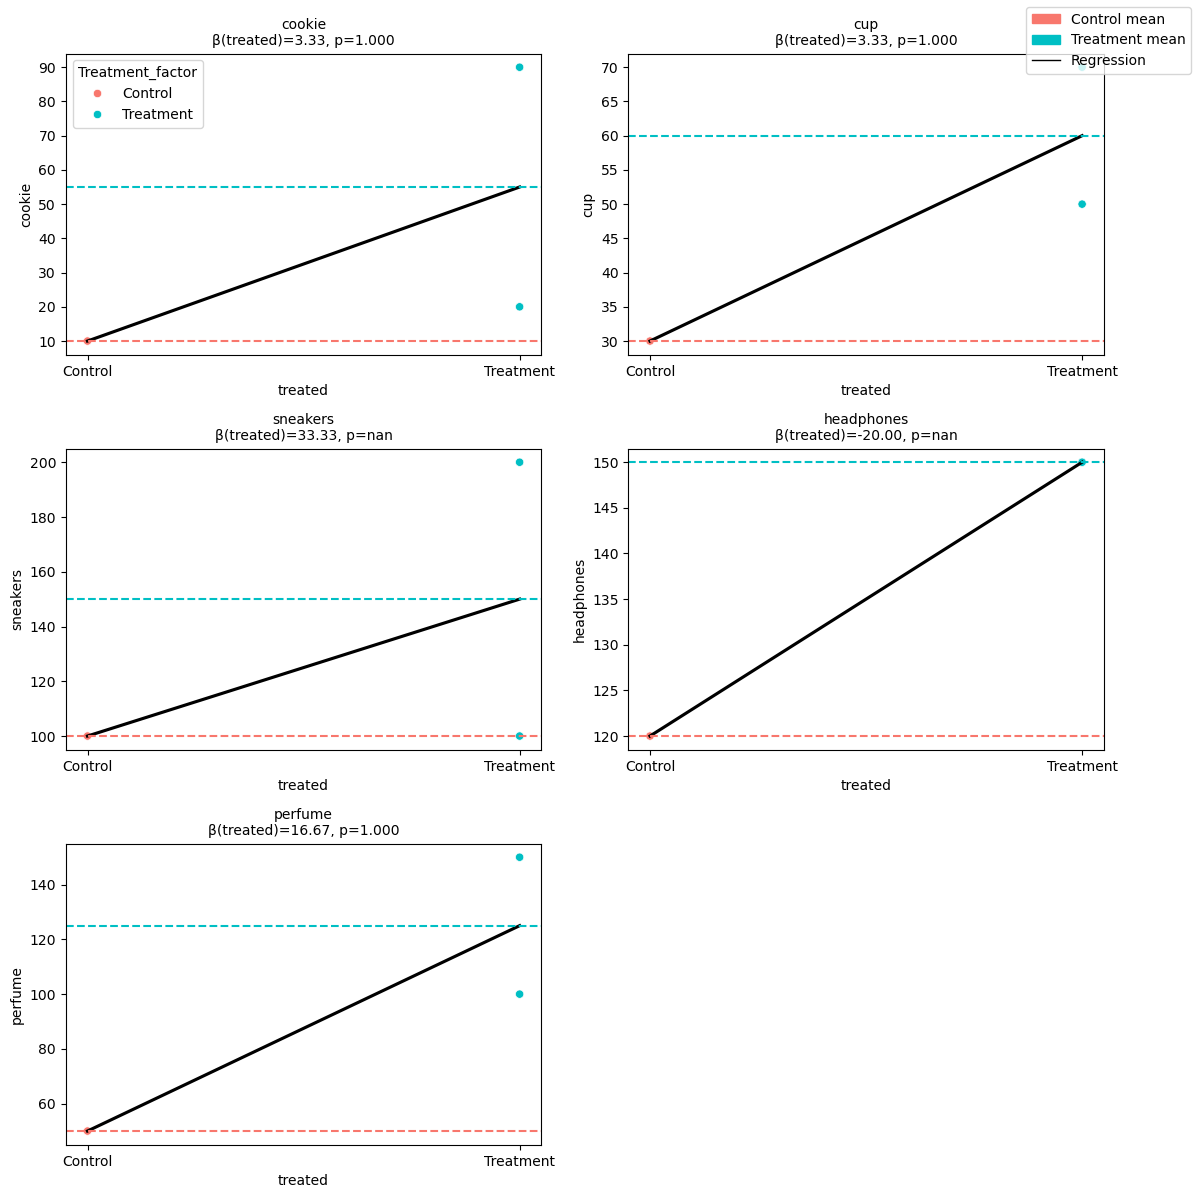

In [32]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('category')
df['Gender'] = df['Gender'].astype('category')  # keeps Male/Female/Third gender/Prefer not to say as-is

if 'Treatment_factor' not in df.columns:
    df['Treatment_factor'] = df['treated'].map({0: 'Control', 1: 'Treatment'})

# --- Regressions with covariates ---
reg_results = {}
covariate_formula = 'treated + C(Age) + C(Gender) + shopping_freq'  # <-- C(Gender) added

for col in cols_present:
    df_reg = df[[col, 'treated', 'Age', 'Gender', 'shopping_freq']].copy()
    for c in [col, 'treated', 'shopping_freq']:
        df_reg[c] = pd.to_numeric(df_reg[c], errors='coerce')
    df_reg['Age'] = df_reg['Age'].astype('category')
    df_reg['Gender'] = df_reg['Gender'].astype('category')
    df_reg = df_reg.dropna()

    lm = smf.ols(formula=f'{col} ~ {covariate_formula}', data=df_reg)
    fit = lm.fit(cov_type='HC1')
    reg_results[col] = fit

    print(f"\n=== {col} ~ treatment + covariates (n={df_reg.shape[0]}) ===\n")
    print(fit.params.to_frame('coef').join(fit.pvalues.to_frame('p-value')).round(4))
    print(f"R²: {fit.rsquared:.4f}")

# --- Plots ---
n = len(cols_present)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

custom_palette = {'Control': '#F8776D', 'Treatment': '#00BFC4'}

for i, col in enumerate(cols_present):
    ax = axes[i // ncols][i % ncols]
    series = pd.to_numeric(df[col], errors='coerce')
    mean_ctr = series[df['treated'] == 0].mean()
    mean_trt = series[df['treated'] == 1].mean()

    show_legend = (i == 0)
    sns.scatterplot(data=df, x='treated', y=col, hue='Treatment_factor',
                    palette=custom_palette, ax=ax, legend=show_legend)
    sns.regplot(data=df, x='treated', y=col, scatter=False, color='black',
                ci=None, ax=ax)
    ax.axhline(mean_ctr, linestyle='--', color=custom_palette['Control'])
    ax.axhline(mean_trt, linestyle='--', color=custom_palette['Treatment'])

    coef = reg_results[col].params['treated']
    pval = reg_results[col].pvalues['treated']
    ax.set_title(f"{col}\nβ(treated)={coef:.2f}, p={pval:.3f}", fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Control', 'Treatment'])

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

handles = [
    mpatches.Patch(color=custom_palette['Control'], label='Control mean'),
    mpatches.Patch(color=custom_palette['Treatment'], label='Treatment mean'),
    plt.Line2D([0], [0], color='black', lw=1, label='Regression'),
]
fig.legend(handles=handles, loc='upper right')
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()